In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Structured Tabular Data

Pima Indians Diabetes Database

https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

## Context
This dataset originates from the National Institute of Diabetes and Digestive and Kidney Diseases. Its objective is to predict whether a patient has diabetes based on diagnostic measurements. The dataset includes only female patients of Pima Indian heritage who are at least 21 years old.

## Content
The dataset contains several medical predictor variables and one target variable, **Outcome**. Predictor variables include factors such as the number of pregnancies, BMI, insulin level, age, and other related medical attributes.

Acknowledgements:
Smith, J.W., Everhart, J.E., Dickson, W.C., Knowler, W.C., & Johannes, R.S. (1988). Using the ADAP learning algorithm to forecast the onset of diabetes mellitus. In *Proceedings of the Symposium on Computer Applications and Medical Care* (pp. 261--265). IEEE Computer Society Press.


# Data Understanding and Preparation

## Dataset Import and semantics
- *import the dataset*
- try to understand:
    - the dataset in general,
    - the dimensionality,
    - the variables and their type. (are they parsed correctly when you import the dataset?)


In [2]:
df = pd.read_csv("./Data/diabetes_v2.csv")

In [3]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,PhysicalActivity
0,6,148,72,35,0,33.6,0.627,50,1,Moderate
1,1,85,66,29,0,26.6,0.351,31,0,Low
2,8,183,64,0,0,23.3,0.672,32,1,Moderate
3,1,89,66,23,94,28.1,0.167,21,0,Moderate
4,0,137,40,35,168,43.1,2.288,33,1,Moderate
...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,Low
764,2,122,70,27,0,36.8,0.340,27,0,High
765,5,121,72,23,112,26.2,0.245,30,0,Moderate
766,1,126,60,0,0,30.1,0.349,47,1,Low


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
 9   PhysicalActivity          768 non-null    object 
dtypes: float64(2), int64(7), object(1)
memory usage: 60.1+ KB


### Accessing Data

In [5]:
# row 10
print(df.iloc[10, :])

Pregnancies                     4
Glucose                       110
BloodPressure                  92
SkinThickness                   0
Insulin                         0
BMI                          37.6
DiabetesPedigreeFunction    0.191
Age                            30
Outcome                         0
PhysicalActivity             High
Name: 10, dtype: object


In [6]:
# column 8
print(df.iloc[:, 8])

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


In [7]:
# column 7-8
print(df.iloc[:, 7:8])

     Age
0     50
1     31
2     32
3     21
4     33
..   ...
763   63
764   27
765   30
766   47
767   23

[768 rows x 1 columns]


In [8]:
# rows 1-2 column 7-8
print(df.iloc[1:3, 7:9])

   Age  Outcome
1   31        0
2   32        1


In [9]:
# entry 4, 5
print(df.iloc[4, 5])

43.1


In [10]:
# column Pregnancies (as a pd.Series)
print(df["Pregnancies"])

0       6
1       1
2       8
3       1
4       0
       ..
763    10
764     2
765     5
766     1
767     1
Name: Pregnancies, Length: 768, dtype: int64


In [11]:
# column Pregnancies (as a pd.DataFrame)
print(df[["Pregnancies"]])

     Pregnancies
0              6
1              1
2              8
3              1
4              0
..           ...
763           10
764            2
765            5
766            1
767            1

[768 rows x 1 columns]


In [12]:
# columns Pregnancies, BMI
print(df[["Pregnancies", "BMI"]])

     Pregnancies   BMI
0              6  33.6
1              1  26.6
2              8  23.3
3              1  28.1
4              0  43.1
..           ...   ...
763           10  32.9
764            2  36.8
765            5  26.2
766            1  30.1
767            1  30.4

[768 rows x 2 columns]


In [13]:
# columns Pregnancies, BMI
print(df.loc[:, ["Pregnancies", "BMI"]])

     Pregnancies   BMI
0              6  33.6
1              1  26.6
2              8  23.3
3              1  28.1
4              0  43.1
..           ...   ...
763           10  32.9
764            2  36.8
765            5  26.2
766            1  30.1
767            1  30.4

[768 rows x 2 columns]


In [14]:
# columns Pregnancies, BMI, row 3
print(df.loc[3, ["Pregnancies", "BMI"]])

Pregnancies       1
BMI            28.1
Name: 3, dtype: object


In [15]:
# filtering df based on Age >= 30
df[df["Age"] >= 30]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,PhysicalActivity
0,6,148,72,35,0,33.6,0.627,50,1,Moderate
1,1,85,66,29,0,26.6,0.351,31,0,Low
2,8,183,64,0,0,23.3,0.672,32,1,Moderate
4,0,137,40,35,168,43.1,2.288,33,1,Moderate
5,5,116,74,0,0,25.6,0.201,30,0,High
...,...,...,...,...,...,...,...,...,...,...
761,9,170,74,31,0,44.0,0.403,43,1,Moderate
762,9,89,62,0,0,22.5,0.142,33,0,High
763,10,101,76,48,180,32.9,0.171,63,0,Low
765,5,121,72,23,112,26.2,0.245,30,0,Moderate


In [16]:
# filtering df based on Age >= 50 or Age <30
df[(df["Age"] >= 50) | (df["Age"] < 30)]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,PhysicalActivity
0,6,148,72,35,0,33.6,0.627,50,1,Moderate
3,1,89,66,23,94,28.1,0.167,21,0,Moderate
6,3,78,50,32,88,31.0,0.248,26,1,High
7,10,115,0,0,0,35.3,0.134,29,0,Low
8,2,197,70,45,543,30.5,0.158,53,1,Low
...,...,...,...,...,...,...,...,...,...,...
759,6,190,92,0,0,35.5,0.278,66,1,Low
760,2,88,58,26,16,28.4,0.766,22,0,High
763,10,101,76,48,180,32.9,0.171,63,0,Low
764,2,122,70,27,0,36.8,0.340,27,0,High


### Basic dataset infos

In [17]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [18]:
df.describe(include="all")

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,PhysicalActivity
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,324
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958,NaN
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000,NaN
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000,NaN
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000,NaN
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000,NaN


In [19]:
df.std(numeric_only=True)

Pregnancies                   3.369578
Glucose                      31.972618
BloodPressure                19.355807
SkinThickness                15.952218
Insulin                     115.244002
BMI                           7.884160
DiabetesPedigreeFunction      0.331329
Age                          11.760232
Outcome                       0.476951
dtype: float64

In [20]:
# map the outcome variable to "Negative" and "Positive"
df["Outcome"] = df["Outcome"].map({0: "Negative", 1: "Positive"})

In [21]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
PhysicalActivity            0
dtype: int64

### Exercises
#### 1. `.iloc` practice (rows + columns)

1. Extract rows 10 to 14 (inclusive) and columns 2 to 5 (inclusive).
2. Print the result and its shape.


#### 2. `.loc` practice with labels

Select rows 10 to 14 (inclusive) and the columns:
"Glucose", "BloodPressure", "SkinThickness", "Insulin"

(Do it with `.loc`.)

#### 3. Filtering

How many patient:
- have BMI greater than 35?
- are older than 50 with zero pregnancies?

## Data Understanding
- *understand the distribution of the data with various plots*
    - start to ask questions!
    - *are there variables that are particularly interesting?*


In [22]:
df_num = df.drop(columns=["PhysicalActivity", "Outcome"])
df_num

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [23]:
df_cat = df[["PhysicalActivity", "Outcome"]]
df_cat

,PhysicalActivity,Outcome
0,Moderate,Positive
1,Low,Negative
2,Moderate,Positive
3,Moderate,Negative
4,Moderate,Positive
...,...,...
763,Low,Negative
764,High,Negative
765,Moderate,Negative
766,Low,Positive


In [24]:
df_all = pd.concat([df_num, df_cat], axis=1)

### Correlation matrix

<Axes: >

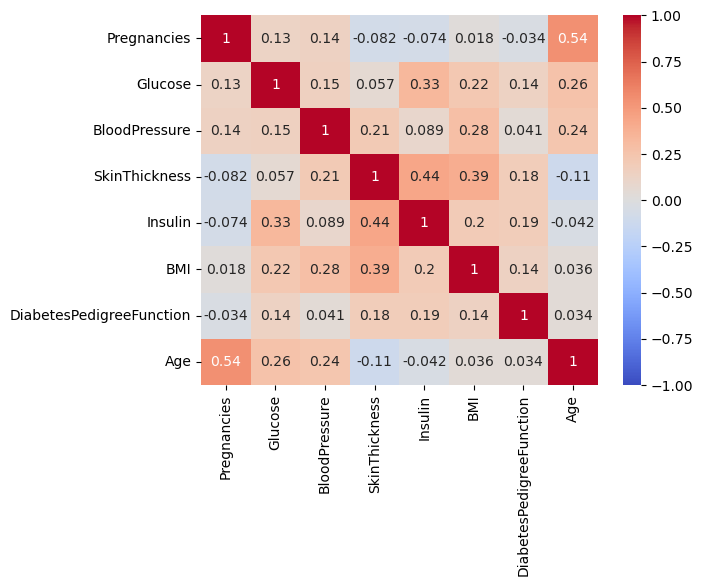

In [25]:
sns.heatmap(df_num.corr(), annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)

### Histograms

array([[<Axes: title={'center': 'Pregnancies'}>]], dtype=object)

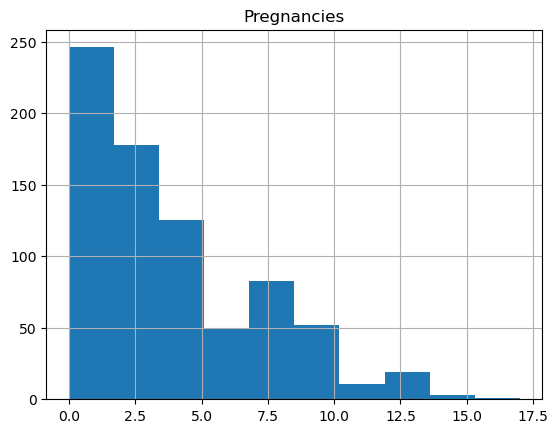

In [26]:
df[["Pregnancies"]].hist(bins=10)

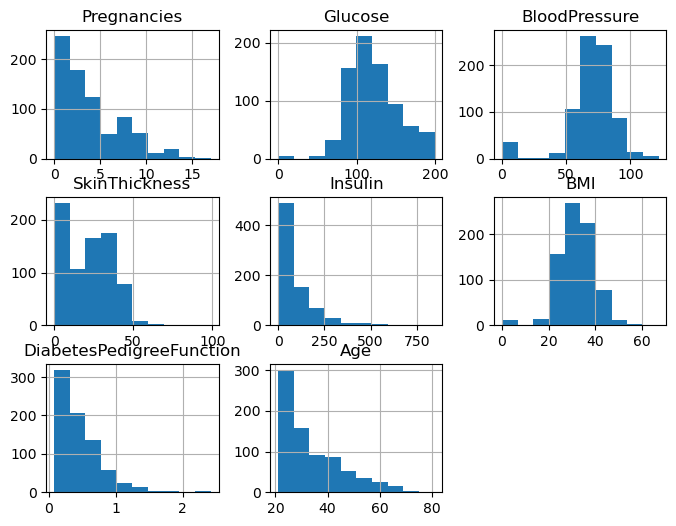

In [27]:
# distribuzione degli score
df_num.hist(figsize=(8,6))
plt.show()

<Axes: xlabel='Glucose', ylabel='Density'>

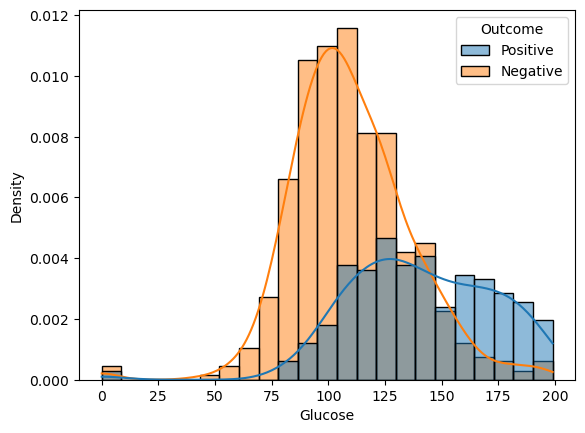

In [28]:
sns.histplot(data=df_all, x="Glucose", hue="Outcome", kde=True, stat="density")

<Axes: xlabel='Glucose', ylabel='Density'>

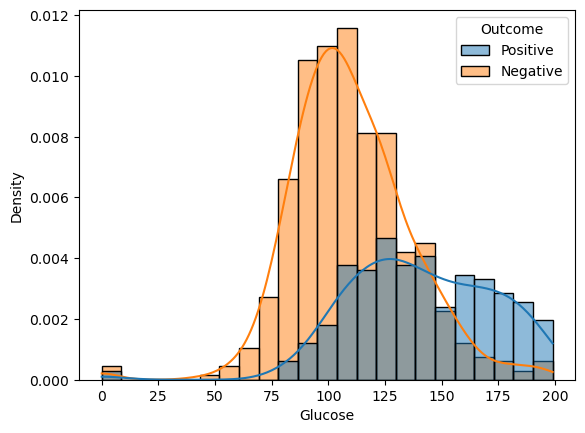

In [29]:
sns.histplot(data=df_all, x="Glucose", hue="Outcome", kde=True, stat="density")

### Count Plots

<BarContainer object of 2 artists>

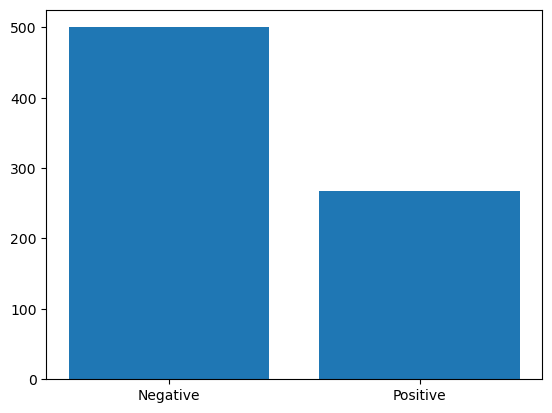

In [30]:
value, count = np.unique(df["Outcome"].values, return_counts=True)
plt.bar(value, count)

In [31]:
list(df[["Outcome"]].value_counts().index)

[('Negative',), ('Positive',)]

In [32]:
df[["Outcome"]].value_counts()

Outcome 
Negative    500
Positive    268
Name: count, dtype: int64

<Axes: xlabel='Outcome', ylabel='count'>

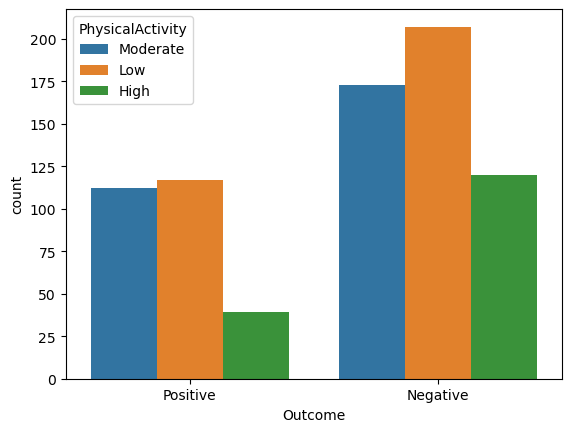

In [33]:
# categoriche
sns.countplot(df_cat, x="Outcome", hue="PhysicalActivity")

<Axes: xlabel='PhysicalActivity', ylabel='count'>

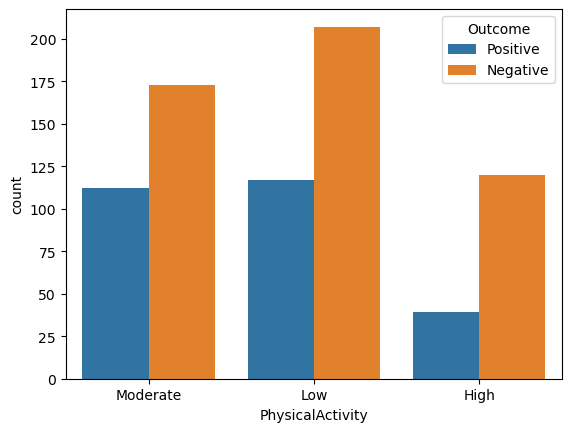

In [34]:
# categoriche
sns.countplot(df_cat, x="PhysicalActivity", hue="Outcome")

In [35]:
def crosstab(df, a, b):
    return pd.crosstab(df[a], df[b]).div(pd.crosstab(df[a], df[b]).sum(axis=1), axis=0)

<Axes: xlabel='Outcome'>

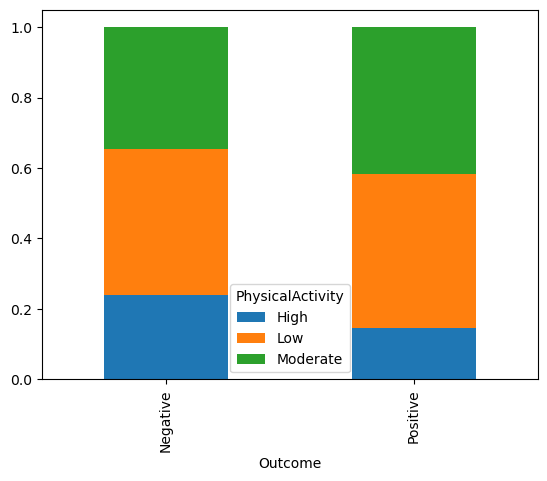

In [36]:
crosstab(df_all, "Outcome", "PhysicalActivity").plot(kind="bar", stacked=True)

### Boxplots

<Axes: >

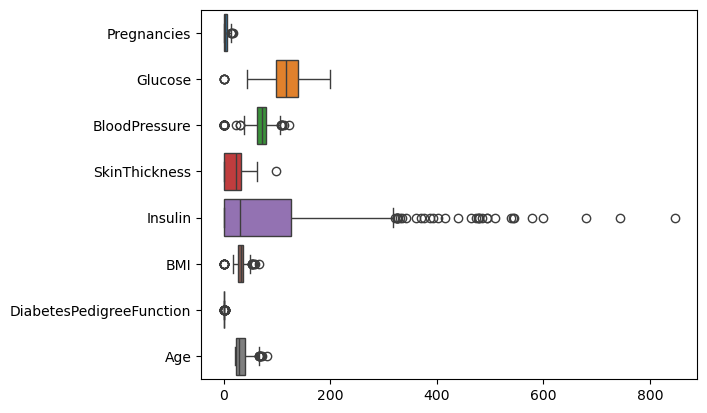

In [37]:
sns.boxplot(df_num, orient="h")
# plt.xscale("log")

### Stripplots and Scatterplots

<Axes: xlabel='Outcome', ylabel='SkinThickness'>

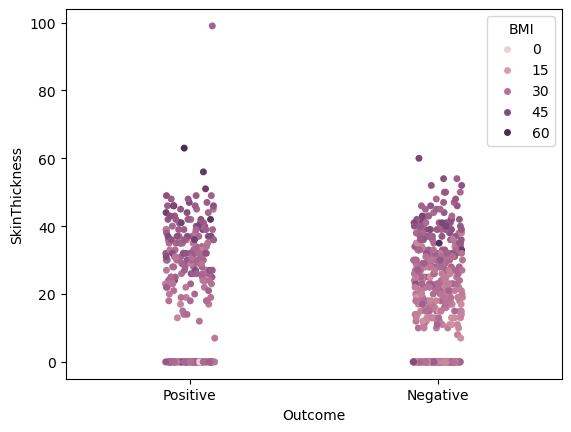

In [38]:
sns.stripplot(
    data=df, x="Outcome", y="SkinThickness", hue="BMI"
)

<Axes: xlabel='PhysicalActivity', ylabel='SkinThickness'>

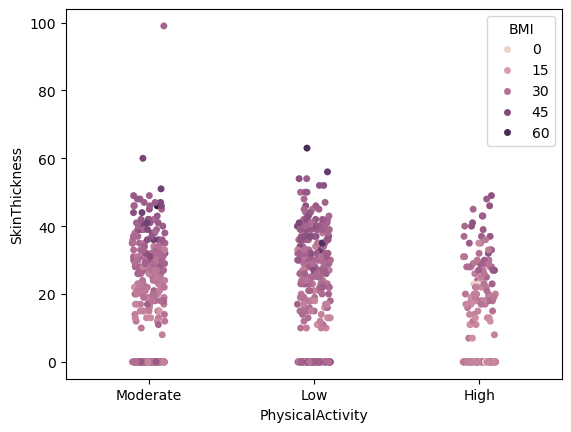

In [39]:
sns.stripplot(
    data=df, x="PhysicalActivity", y="SkinThickness", hue="BMI"
)

<Axes: xlabel='SkinThickness', ylabel='BMI'>

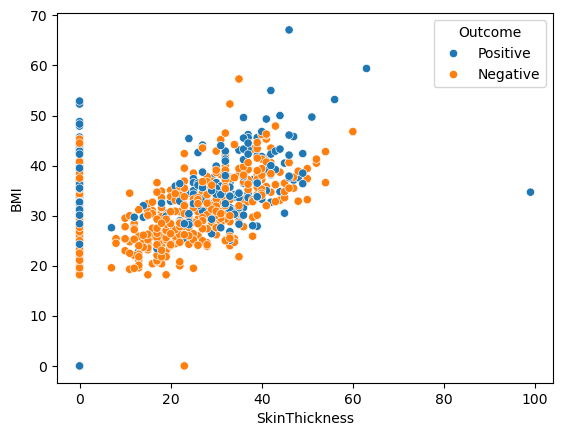

In [40]:
sns.scatterplot(data=df, y="BMI", x="SkinThickness", hue="Outcome")

<Axes: xlabel='Glucose', ylabel='BMI'>

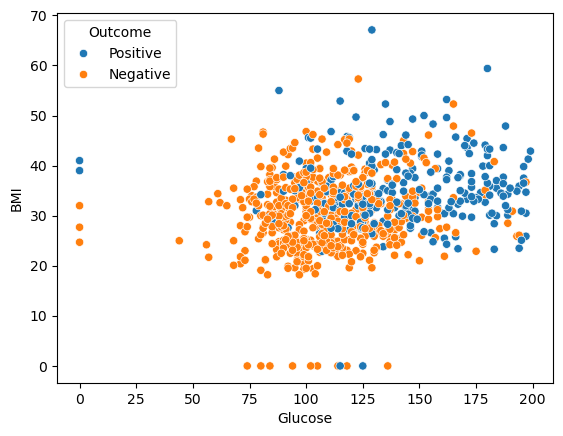

In [41]:
sns.scatterplot(data=df, y="BMI", x="Glucose", hue="Outcome")

### Scatter Matrix
This is horrible to read, but it is a useful tool to quickly check for correlations between features and the target variable. Avoid it in the project report

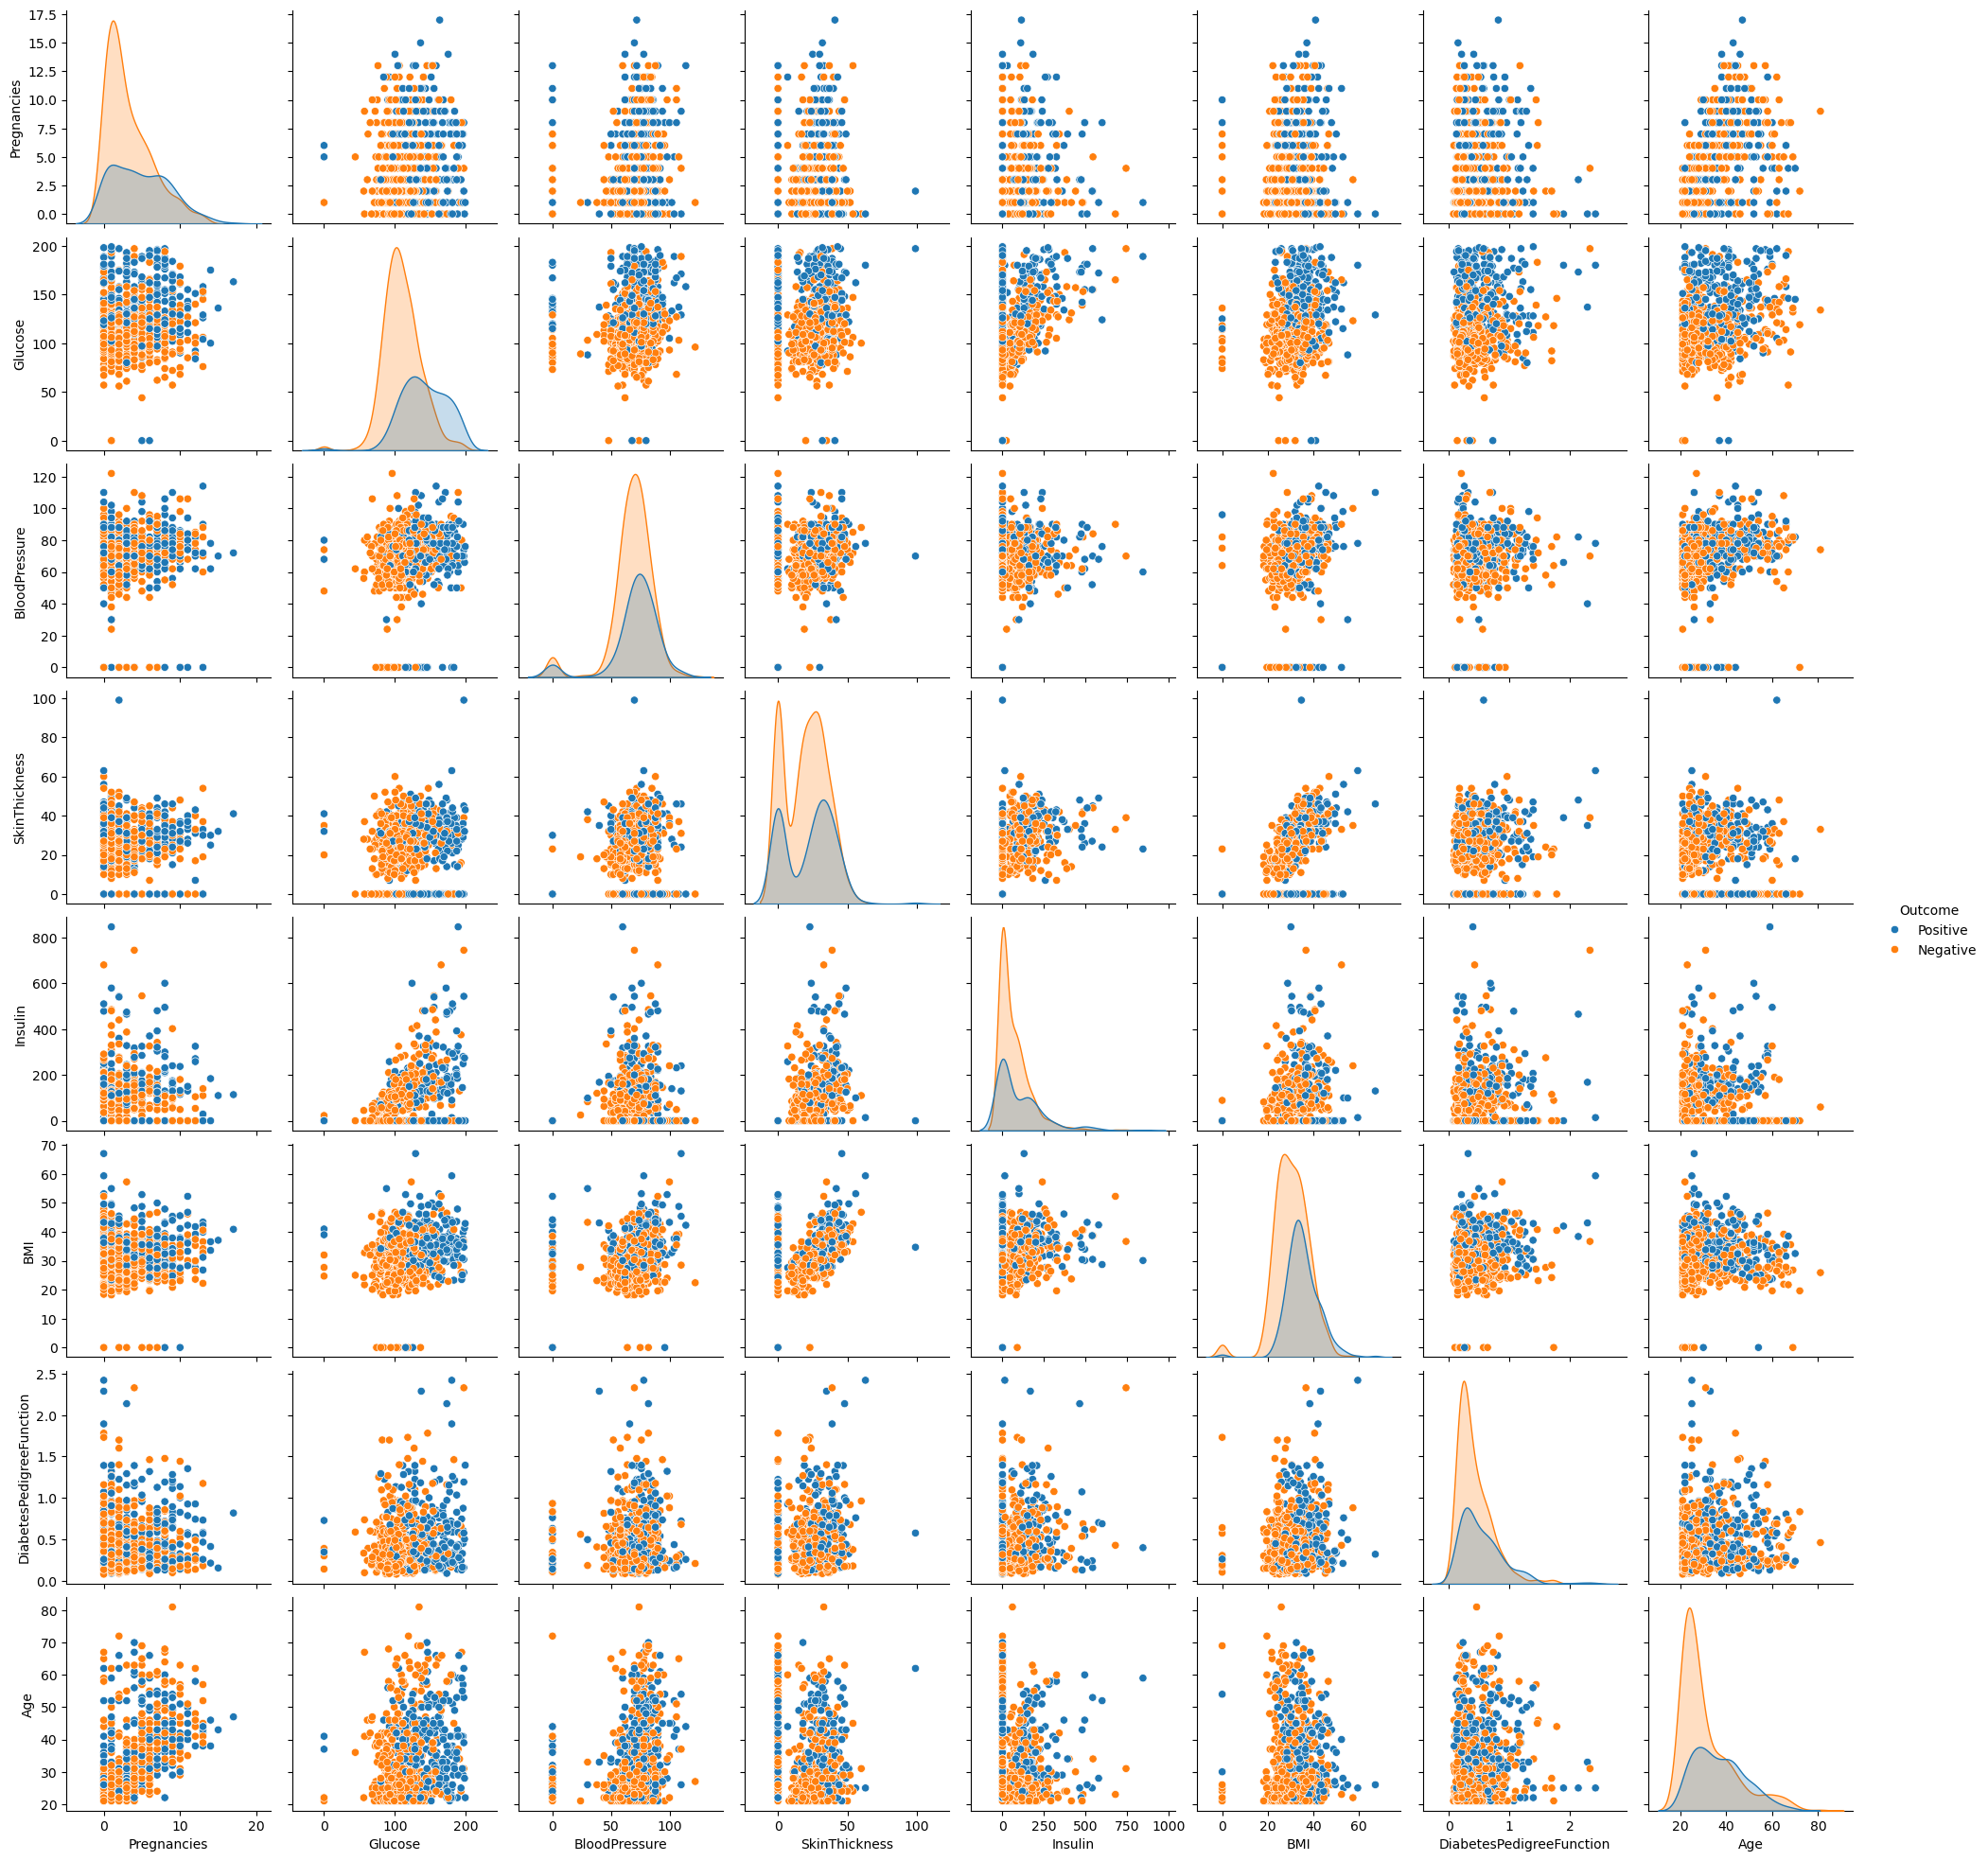

In [42]:
sns.pairplot(df, hue="Outcome")

### Exercises

- Plot a scatter matrix with colors that are based on PhysicalActivity. If some scatter in the matrix is particularly interesting, plot it separately
- Plot a countplot that, for each PhysicalActivity level, shows the percentage of Positive and Negative (*hint: crosstab*)
- Given the boxplot above, return the dataset containing only the fliers for the Insuline

## Data Quality
- *check for missing values, duplicates, redundant variables, outliers*
- *handle these issues*

In [43]:
# check for duplicates
df_all.duplicated().sum()

0

In [44]:
# does zero really mean zero?
(df_all == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
PhysicalActivity              0
Outcome                       0
dtype: int64

In [45]:
# replace zeros with NaN for certain columns
cols_with_zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df_clean = df.copy()
df_clean[cols_with_zero_as_missing] = df[cols_with_zero_as_missing].replace(0, np.nan)

In [46]:
# now let's check again for missing values
df_clean.isna().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
PhysicalActivity              0
dtype: int64

In [47]:
# let's one hot encode the PhysicalActivity column
df_clean = pd.concat([df_clean, pd.get_dummies(df_clean[["PhysicalActivity"]]).astype(int)], axis=1)
df_clean = df_clean.drop(["PhysicalActivity"], axis=1)

In [48]:
df_clean

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,PhysicalActivity_High,PhysicalActivity_Low,PhysicalActivity_Moderate
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,Positive,0,0,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,Negative,0,1,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,Positive,0,0,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,Negative,0,0,1
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,Positive,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,Negative,0,1,0
764,2,122.0,70.0,27.0,NaN,36.8,0.340,27,Negative,1,0,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,Negative,0,0,1
766,1,126.0,60.0,NaN,NaN,30.1,0.349,47,Positive,0,1,0


# Unstructured Data

## Time Series

In [73]:
import json

In [74]:
X = np.load("./Data/ECG200_X.npy")
y = np.load("./Data/ECG200_y.npy")
with open("./Data/ECG200_meta.json", "r") as f:
    meta = json.load(f)
X.shape, y.shape, np.unique(y)

((5000, 1, 140), (5000,), array(['1', '2', '3', '4', '5'], dtype='<U1'))

In [75]:
meta

{'problemname': 'ecg5000',
 'timestamps': False,
 'missing': False,
 'univariate': True,
 'equallength': True,
 'classlabel': True,
 'targetlabel': False,
 'class_values': ['1', '2', '3', '4', '5']}

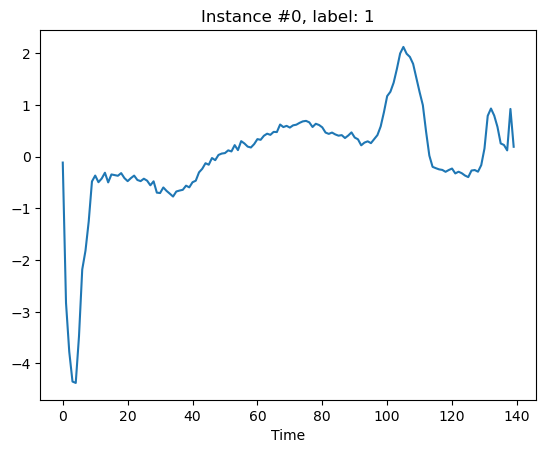

In [76]:
i = 0
plt.title(f"Instance #{i}, label: {y[i]}")
plt.plot(X[0, 0])
plt.xlabel("Time")
plt.show()

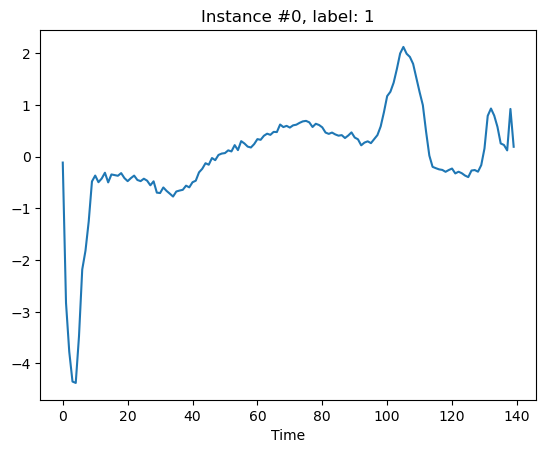

In [77]:
i = 0
plt.title(f"Instance #{i}, label: {y[i]}")
sns.lineplot(X[0, 0])
plt.xlabel("Time")
plt.show()

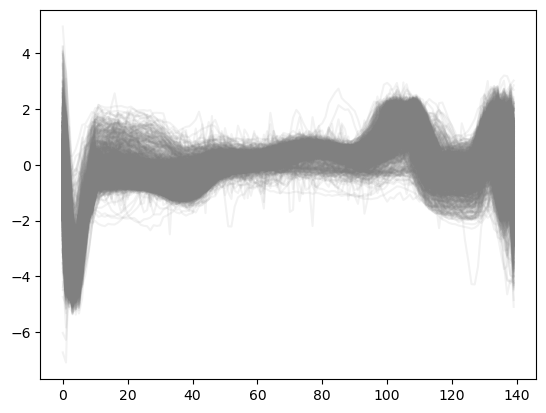

In [78]:
class_1_ts = np.argwhere(y == "1")
X_class_1 = X[class_1_ts[:, 0]]

plt.plot(X_class_1[:, 0].T, color="gray", alpha=0.1)
plt.show()

/var/folders/kj/v66zvn217x31k6lx63lt02q40000gn/T/ipykernel_5668/2192123442.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


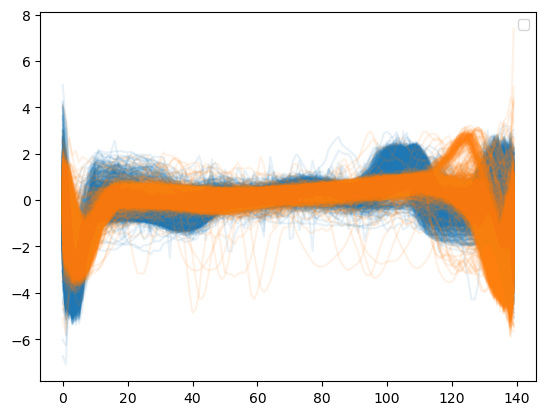

In [79]:
class_2_ts = np.argwhere(y == "2")
X_class_2 = X[class_2_ts[:, 0]]

plt.plot(X_class_1[:, 0].T, color="C0", alpha=0.1)
plt.plot(X_class_2[:, 0].T, color="C1", alpha=0.1)
plt.legend()
plt.show()

### Sound Waves
https://zenodo.org/records/4008297
sound waves are time series

In [80]:
import zipfile
import io
import numpy as np
from scipy.io import wavfile
from tqdm import tqdm  # optional, for progress

# Path to your downloaded ZIP
zip_path = "./Data/meows.zip"

# Dictionary to store results
audio_data = {}  # {filename: (sample_rate, numpy_array)}

with zipfile.ZipFile(zip_path, 'r') as z:
    # List only .wav files
    wav_files = [f for f in z.namelist() if f.lower().endswith('.wav')]

    for fname in tqdm(wav_files, desc="Reading WAV files"):
        with z.open(fname) as file_in_zip:
            # Read file bytes into a BytesIO buffer
            audio_bytes = io.BytesIO(file_in_zip.read())

            # Use scipy to read WAV data
            sr, data = wavfile.read(audio_bytes)  # sr = sample rate

            # Convert to float32 normalized between -1 and 1 (optional)
            if data.dtype == np.int16:
                data = data.astype(np.float32) / 32768.0

            audio_data[fname] = (sr, data)

print(f"Loaded {len(audio_data)} WAV files.")

/var/folders/kj/v66zvn217x31k6lx63lt02q40000gn/T/ipykernel_5668/1892898887.py:23: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, data = wavfile.read(audio_bytes)  # sr = sample rate
Reading WAV files: 100%|████████████████████| 440/440 [00:00<00:00, 6106.36it/s]

Loaded 440 WAV files.


In [81]:
audio_data.keys()

dict_keys(['dataset/F_MAG01_EU_FN_FED01_106.wav', 'dataset/I_NUL01_MC_MI_SIM01_304.wav', 'dataset/I_MEG01_MC_FI_SIM01_304.wav', 'dataset/B_CAN01_EU_FN_GIA01_205.wav', 'dataset/F_MAG01_EU_FN_FED01_304.wav', 'dataset/F_MIN01_EU_FN_BEN01_102.wav', 'dataset/F_WHO01_MC_FI_SIM01_304.wav', 'dataset/F_IND01_EU_FN_ELI01_302.wav', 'dataset/F_BAC01_MC_MN_SIM01_103.wav', 'dataset/I_WHO01_MC_FI_SIM01_103.wav', 'dataset/I_BLE01_EU_FN_DEL01_103.wav', 'dataset/F_BAC01_MC_MN_SIM01_301.wav', 'dataset/I_BLE01_EU_FN_DEL01_301.wav', 'dataset/I_WHO01_MC_FI_SIM01_301.wav', 'dataset/B_BRA01_MC_MN_SIM01_301.wav', 'dataset/I_NIG01_MC_MN_SIM01_201.wav', 'dataset/F_MEG01_MC_FI_SIM01_301.wav', 'dataset/I_MIN01_EU_FN_BEN01_106.wav', 'dataset/B_MAT01_EU_FN_RIT01_101.wav', 'dataset/I_WHO01_MC_FI_SIM01_116.wav', 'dataset/I_WHO01_MC_FI_SIM01_102.wav', 'dataset/I_BLE01_EU_FN_DEL01_102.wav', 'dataset/F_BAC01_MC_MN_SIM01_102.wav', 'dataset/F_MIN01_EU_FN_BEN01_103.wav', 'dataset/B_CAN01_EU_FN_GIA01_210.wav', 'dataset/F_MAG

In [82]:
i = 0
sr, audio = audio_data[list(audio_data.keys())[i]]

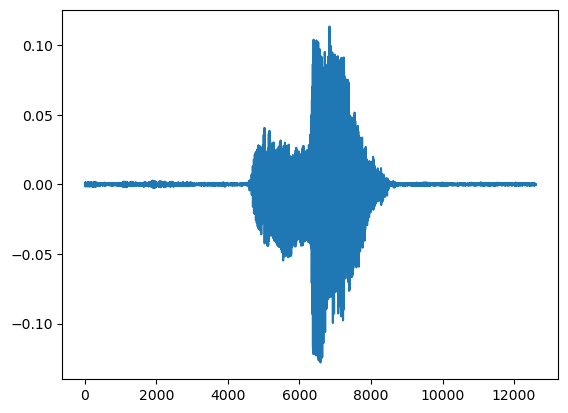

In [83]:
plt.plot(audio)
plt.show()

In [84]:
from IPython.display import Audio

Audio(audio, rate=sr)

## Images

In [85]:
from sklearn.datasets import load_digits

In [86]:
from sklearn.datasets import load_digits
digits = load_digits()
print(digits.data.shape)

(1797, 64)


In [87]:
digits.images.shape

(1797, 8, 8)

In [88]:
digits.data

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]])

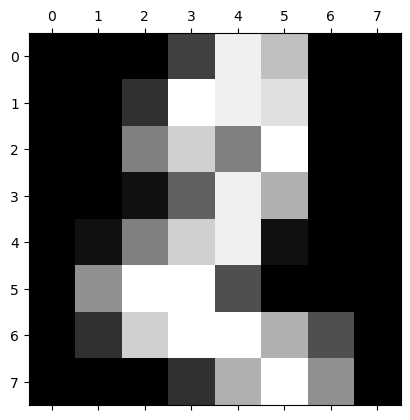

In [89]:
import matplotlib.pyplot as plt
plt.matshow(digits.images[2], cmap="gray")
plt.show()

## Text
https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_20newsgroups_vectorized.html#sklearn.datasets.fetch_20newsgroups_vectorized

Text data can come in many different forms. Here is a classical text dataset from sklearn. We will learn how to deal with it, but for now let's at least import it


In [90]:
from sklearn.datasets import fetch_20newsgroups

data = fetch_20newsgroups()

In [91]:
data.keys()

dict_keys(['data', 'filenames', 'target_names', 'target', 'DESCR'])

In [92]:
print(data["DESCR"])

.. _20newsgroups_dataset:

The 20 newsgroups text dataset
------------------------------

The 20 newsgroups dataset comprises around 18000 newsgroups posts on
20 topics split in two subsets: one for training (or development)
and the other one for testing (or for performance evaluation). The split
between the train and test set is based upon a messages posted before
and after a specific date.

This module contains two loaders. The first one,
:func:`sklearn.datasets.fetch_20newsgroups`,
returns a list of the raw texts that can be fed to text feature
extractors such as :class:`~sklearn.feature_extraction.text.CountVectorizer`
with custom parameters so as to extract feature vectors.
The second one, :func:`sklearn.datasets.fetch_20newsgroups_vectorized`,
returns ready-to-use features, i.e., it is not necessary to use a feature
extractor.

**Data Set Characteristics:**

=================   ==========
Classes                     20
Samples total            18846
Dimensionality               1

In [93]:
print(data.data[0])

From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----







In [94]:
data["target_names"]

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

In [95]:
data.target[0]

7